In [1]:
#### ------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: Jun 2, 2025
#### Compute 12 NPIFs from immune-only nuclei based on HoverNet prediction, using MPP = 0.248
#### Removes outliers for Major Axis and Minor Axis using IQR
#### Filters top 25% tiles based on number of immune nuclei
#### ------------------------------------------------------------------------------------------

import os
import pandas as pd
import numpy as np

# Set working directory
_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.makedirs(_wpath_, exist_ok=True)
os.chdir(_wpath_)
print("Working directory:", _wpath_)

# Define dataset and paths
dataset_name = "CPTAC_BRCA"
input_folder = f"{dataset_name}/HoverNet/outputs/"
output_file_path = f"{dataset_name}/HoverNet/outputs/CPTAC_BRCA_HoverNet_ImmuneOnly_NPIFs_Filtered_Tiles_Top25Q.csv"

columns_to_compute = ["Area", "Major Axis", "Minor Axis", "Perimeter", "Eccentricity", "Circularity"]
MPP = 0.248  # microns per pixel for 40X

# Function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Store results
results = []

# Loop over all immune-only slide feature files
slide_dirs = [f for f in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, f)) and f.endswith("_tiles")]

for slide_name in slide_dirs:
    file_path = os.path.join(input_folder, slide_name, "features3", f"{slide_name}.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}, skipping...")
        continue

    df = pd.read_csv(file_path)

    # Convert units
    df["Area"] = df["Area"] * (MPP ** 2)
    df["Major Axis"] = df["Major Axis"] * MPP
    df["Minor Axis"] = df["Minor Axis"] * MPP
    df["Perimeter"] = df["Perimeter"] * MPP

    # Remove outliers
    df = remove_outliers(df, "Major Axis")
    df = remove_outliers(df, "Minor Axis")

    # Count immune nuclei per tile
    tile_nucleus_counts = df.groupby("Tile")["Nucleus ID"].count().reset_index()
    tile_nucleus_counts.rename(columns={"Nucleus ID": "Immune_Nucleus_Count"}, inplace=True)

    total_tiles = tile_nucleus_counts.shape[0]
    percentile_75 = tile_nucleus_counts["Immune_Nucleus_Count"].quantile(0.75)
    top_tiles = tile_nucleus_counts[tile_nucleus_counts["Immune_Nucleus_Count"] >= percentile_75]

    num_filtered_tiles = top_tiles.shape[0]

    print(f"Slide: {slide_name}")
    print(f"  - Total tiles with immune nuclei: {total_tiles}")
    print(f"  - 75th percentile threshold: {percentile_75}")
    print(f"  - Top 25% tiles: {num_filtered_tiles}")

    # Filter DF for selected tiles
    df_filtered = df[df["Tile"].isin(top_tiles["Tile"])]
    
    if df_filtered.empty:
        print(f"  - No valid tiles in top 25% for slide {slide_name}, skipping...\n")
        continue

    # Compute mean and std of features
    mean_values = df_filtered[columns_to_compute].mean()
    std_values = df_filtered[columns_to_compute].std()

    # Append result
    results.append([slide_name, total_tiles, num_filtered_tiles] + mean_values.tolist() + std_values.tolist())

# Format results
result_df = pd.DataFrame(
    results,
    columns=["Slide_Name", "Total_Tiles", "Filtered_Tiles"] + 
            [f"Mean {col}" for col in columns_to_compute] + 
            [f"Std {col}" for col in columns_to_compute]
)

# Clean up values
result_df.replace([np.inf, -np.inf], np.nan, inplace=True)
result_df.fillna(result_df.mean(numeric_only=True), inplace=True)
result_df.fillna(0, inplace=True)

# Save results
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
result_df.to_csv(output_file_path, index=False)

print(f"\nImmune-only NPIFs (Top 25% tiles) saved to: {output_file_path}")


Working directory: /data/Lab_ruppin/Ranjan/HnE/
Slide: 03BR011-3a210a6b-bdf1-4407-94c8-7bb085_275_tiles
  - Total tiles with immune nuclei: 270
  - 75th percentile threshold: 34.0
  - Top 25% tiles: 70
Slide: 13BR003-dc061ec0-a115-4905-be45-83ec1c_281_tiles
  - Total tiles with immune nuclei: 281
  - 75th percentile threshold: 16.0
  - Top 25% tiles: 77
Slide: 05BR026-c19af02c-8e00-4169-9d43-c60995_312_tiles
  - Total tiles with immune nuclei: 310
  - 75th percentile threshold: 11.0
  - Top 25% tiles: 86
Slide: 05BR040-4ca1e8bc-0c34-42bf-80c9-271517_374_tiles
  - Total tiles with immune nuclei: 359
  - 75th percentile threshold: 20.0
  - Top 25% tiles: 91
Slide: 01BR002-5a2a6cb6-59c1-4eda-b0f2-fbf2b6_304_tiles
  - Total tiles with immune nuclei: 251
  - 75th percentile threshold: 6.0
  - Top 25% tiles: 66
Slide: 01BR021-70c61b95-85f4-4735-b91c-7b18a4_670_tiles
  - Total tiles with immune nuclei: 581
  - 75th percentile threshold: 6.0
  - Top 25% tiles: 151
Slide: 22BR006-cdcc4b54-fcf8-

In [2]:
result_df

,Slide_Name,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,03BR011-3a210a6b-bdf1-4407-94c8-7bb085_275_tiles,270,70,10.282365,4.462884,3.108367,12.578026,0.680906,0.784435,4.418588,1.040087,0.717888,2.841445,0.138173,0.072136
1,13BR003-dc061ec0-a115-4905-be45-83ec1c_281_tiles,281,77,7.806800,3.860985,2.682507,10.840837,0.678963,0.790858,4.006920,1.070561,0.694235,2.888279,0.139545,0.067189
2,05BR026-c19af02c-8e00-4169-9d43-c60995_312_tiles,310,86,6.516503,3.547254,2.484191,9.987318,0.675506,0.790635,2.963865,0.839711,0.569365,2.334322,0.139376,0.070335
3,05BR040-4ca1e8bc-0c34-42bf-80c9-271517_374_tiles,359,91,6.437570,3.486356,2.478618,9.868347,0.659678,0.799069,3.083202,0.893999,0.590646,2.445799,0.145559,0.076774
4,01BR002-5a2a6cb6-59c1-4eda-b0f2-fbf2b6_304_tiles,251,66,6.968243,3.720717,2.540882,10.395134,0.691984,0.787644,2.785562,0.866035,0.498136,2.206096,0.132209,0.062884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,01BR023-7aa930f5-4933-4cea-9f24-a132f7_759_tiles,728,188,9.857841,4.328469,3.064305,12.297127,0.662575,0.792466,4.249550,1.061652,0.675385,2.831939,0.146039,0.076847
645,11BR048-951826c2-86b6-44e1-8ca4-142861_1671_tiles,1580,425,6.981191,3.617807,2.580407,10.260475,0.656838,0.797550,3.550375,0.984355,0.624093,2.658491,0.144193,0.074770
646,11BR013-faadb553-9437-42cb-b469-498d67_1645_tiles,1492,395,7.749021,3.813730,2.759293,10.979341,0.650132,0.782179,3.300050,0.885976,0.601463,2.501130,0.143619,0.075791
647,18BR019-3a987590-ed76-44f9-b7e5-e8ea5f_1590_tiles,1560,396,6.480318,3.520358,2.508550,10.139803,0.661812,0.773040,2.745517,0.827066,0.552223,2.431595,0.141850,0.089282


In [3]:
# Extract the patient ID from the first 7 characters of Slide_Name
result_df['Patient_ID'] = result_df['Slide_Name'].str[:7]

# Compute the average feature values across all slides for each patient
patient_avg_df = result_df.groupby('Patient_ID').mean(numeric_only=True)

# Save results to CSV
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)  # Ensure directory exists
patient_avg_df.to_csv(output_file_path)

print(f"Converted results saved to: {output_file_path}")

patient_avg_df

Converted results saved to: CPTAC_BRCA/HoverNet/outputs/CPTAC_BRCA_HoverNet_ImmuneOnly_NPIFs_Filtered_Tiles_Top25Q.csv


,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
Patient_ID,,,,,,,,,,,,,,
01BR001,468.142857,148.000000,7.790775,3.835177,2.743594,10.900192,0.657119,0.788475,3.617815,0.959479,0.636387,2.606768,0.145975,0.068995
01BR002,211.800000,57.600000,6.494223,3.586577,2.467586,10.002955,0.684128,0.793024,2.489104,0.806003,0.477417,2.035953,0.140475,0.068335
01BR003,71.333333,21.000000,7.060268,3.713747,2.558480,10.339035,0.688981,0.800023,3.049651,0.877559,0.547122,2.314689,0.131685,0.060303
01BR004,470.333333,140.666667,7.897880,3.744226,2.815866,10.811927,0.621257,0.814500,3.503209,0.858582,0.630088,2.425828,0.144633,0.060258
01BR005,205.666667,57.833333,6.804545,3.573589,2.575347,10.184859,0.653352,0.795648,2.999788,0.828166,0.554210,2.332588,0.141903,0.071488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22BR005,909.200000,263.000000,7.369211,3.728282,2.657326,10.593930,0.660554,0.792731,3.274181,0.900226,0.589171,2.438282,0.141493,0.068355
22BR006,341.800000,89.400000,4.674415,2.999797,2.147106,8.528905,0.653925,0.785593,1.959682,0.705482,0.422107,1.902809,0.144684,0.081118
22BR007,311.666667,84.666667,6.267108,3.475665,2.431475,9.878961,0.675719,0.770112,3.120451,0.897951,0.607908,2.532221,0.140984,0.076290


In [4]:
patient_avg_df.describe()

,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,944.645555,261.821729,7.065205,3.633166,2.599031,10.323324,0.656573,0.795226,3.194425,0.886348,0.582977,2.419894,0.142991,0.071536
std,787.617198,215.054578,1.139108,0.289863,0.198378,0.813684,0.015383,0.009341,0.650400,0.107469,0.086282,0.305083,0.004836,0.005378
min,28.666667,8.666667,4.439078,2.870803,2.144678,8.231098,0.597223,0.769306,1.501569,0.612805,0.325862,1.582421,0.114387,0.055682
25%,350.916667,98.750000,6.327554,3.457029,2.467861,9.822854,0.647218,0.789283,2.774622,0.811830,0.524008,2.212406,0.141224,0.068270
50%,579.625000,156.666667,7.051693,3.640678,2.601501,10.336830,0.657507,0.795836,3.145375,0.880690,0.580145,2.408390,0.142894,0.071572
75%,1471.062500,396.312500,7.917905,3.832497,2.742928,10.899109,0.666550,0.801158,3.615560,0.958093,0.638418,2.621242,0.144509,0.074557
max,3743.000000,1032.000000,10.228642,4.406921,3.117677,12.446584,0.688981,0.821269,5.135850,1.135015,0.802411,3.165008,0.188752,0.092462


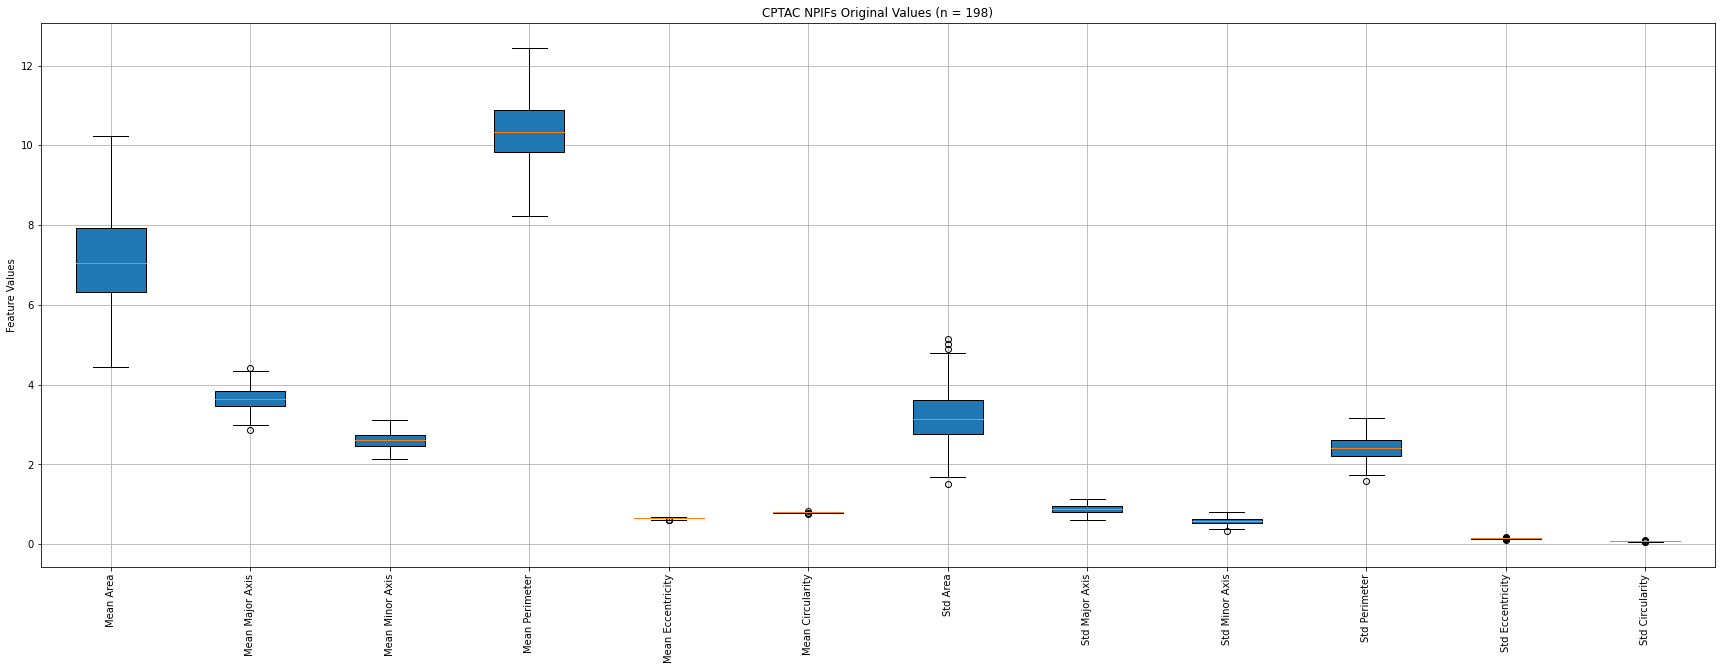

In [5]:
# Import required library
import matplotlib.pyplot as plt

# Select only NPIF features (excluding the first column 'Slide_Name')
cptac_features = patient_avg_df.iloc[:, 2:]

# Number of samples in the dataset
n_cptac = cptac_features.shape[0]

# Plot boxplots for PathAI NPIFs
plt.figure(figsize=(30, 10))
plt.boxplot(cptac_features.values, labels=cptac_features.columns, vert=True, patch_artist=True)
plt.xticks(rotation=90)
plt.title(f"CPTAC NPIFs Original Values (n = {n_cptac})")
plt.ylabel("Feature Values")
plt.grid(True)
plt.show()